In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("D:/Anomaly-Detection/data/raw/cybersecurity_dataset.csv")

In [3]:
df.head(3)

,entity_id,entity_type,timestamp,logout_time,source_ip,geo_location,resource_accessed,auth_method,session_duration,command_sequence,...,normal_resources,login_hour,location_changed,device_changed,auth_changed,login_time_changed,long_session,high_failed_login,resource_changed,risk_score
0,U0001,user,2026-01-01 08:56:33,2026-01-01 10:12:33,155.238.205.51,Bangalore,Internal Server,Password,76,logout -> execute_script -> authenticate -> do...,...,"Internal Server,HR Portal,Database,Email",8,False,False,False,False,False,False,False,0
1,U0002,user,2026-01-01 09:17:28,2026-01-01 11:15:28,154.102.125.213,Pune,CRM,MFA,118,read_file -> upload_file -> authenticate -> op...,...,"VPN,HR Portal,CRM",9,False,False,False,False,False,True,False,1
2,U0003,user,2026-01-01 10:20:26,2026-01-01 11:59:26,241.251.18.193,Bangalore,Confluence,Biometric,99,read_file -> upload_file -> download_file -> l...,...,"Confluence,GitHub,Database,VPN",10,False,False,False,False,False,False,False,0


In [4]:
df.shape

(45000, 43)

In [5]:
df.columns

Index(['entity_id', 'entity_type', 'timestamp', 'logout_time', 'source_ip',
       'geo_location', 'resource_accessed', 'auth_method', 'session_duration',
       'command_sequence', 'device_fingerprint', 'failed_login_attempts',
       'label', 'attack_type', 'name', 'email', 'department', 'office',
       'device_id_x', 'device_type', 'operating_system', 'browser',
       'mac_address', 'normal_entity_type', 'normal_department',
       'normal_geo_location', 'device_id_y', 'normal_device_fingerprint',
       'normal_auth_method', 'normal_login_start', 'normal_login_end',
       'normal_session_duration', 'normal_failed_login_attempts',
       'normal_resources', 'login_hour', 'location_changed', 'device_changed',
       'auth_changed', 'login_time_changed', 'long_session',
       'high_failed_login', 'resource_changed', 'risk_score'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   entity_id                     45000 non-null  str  
 1   entity_type                   45000 non-null  str  
 2   timestamp                     45000 non-null  str  
 3   logout_time                   45000 non-null  str  
 4   source_ip                     45000 non-null  str  
 5   geo_location                  45000 non-null  str  
 6   resource_accessed             45000 non-null  str  
 7   auth_method                   45000 non-null  str  
 8   session_duration              45000 non-null  int64
 9   command_sequence              45000 non-null  str  
 10  device_fingerprint            45000 non-null  str  
 11  failed_login_attempts         45000 non-null  int64
 12  label                         45000 non-null  str  
 13  attack_type                   900 non-null

In [7]:
df.isnull().sum()

entity_id                           0
entity_type                         0
timestamp                           0
logout_time                         0
source_ip                           0
geo_location                        0
resource_accessed                   0
auth_method                         0
session_duration                    0
command_sequence                    0
device_fingerprint                  0
failed_login_attempts               0
label                               0
attack_type                     44100
name                                0
email                               0
department                          0
office                              0
device_id_x                         0
device_type                         0
operating_system                    0
browser                             0
mac_address                         0
normal_entity_type                  0
normal_department                   0
normal_geo_location                 0
device_id_y 

In [8]:
df['attack_type'].value_counts()

attack_type
Low and Slow Brute Force    231
Insider Threat              203
Slow Credential Stuffing    202
Device Spoofing              65
Brute Force                  58
Lateral Movement             49
Impossible Travel            48
Credential Stuffing          44
Name: count, dtype: int64

In [9]:
df.columns

Index(['entity_id', 'entity_type', 'timestamp', 'logout_time', 'source_ip',
       'geo_location', 'resource_accessed', 'auth_method', 'session_duration',
       'command_sequence', 'device_fingerprint', 'failed_login_attempts',
       'label', 'attack_type', 'name', 'email', 'department', 'office',
       'device_id_x', 'device_type', 'operating_system', 'browser',
       'mac_address', 'normal_entity_type', 'normal_department',
       'normal_geo_location', 'device_id_y', 'normal_device_fingerprint',
       'normal_auth_method', 'normal_login_start', 'normal_login_end',
       'normal_session_duration', 'normal_failed_login_attempts',
       'normal_resources', 'login_hour', 'location_changed', 'device_changed',
       'auth_changed', 'login_time_changed', 'long_session',
       'high_failed_login', 'resource_changed', 'risk_score'],
      dtype='str')

In [10]:
df['label'].value_counts()

label
Normal    44100
Attack      900
Name: count, dtype: int64

In [11]:
df["attack_type"] = df["attack_type"].fillna("Normal")

In [12]:
df.isnull().sum()

entity_id                       0
entity_type                     0
timestamp                       0
logout_time                     0
source_ip                       0
geo_location                    0
resource_accessed               0
auth_method                     0
session_duration                0
command_sequence                0
device_fingerprint              0
failed_login_attempts           0
label                           0
attack_type                     0
name                            0
email                           0
department                      0
office                          0
device_id_x                     0
device_type                     0
operating_system                0
browser                         0
mac_address                     0
normal_entity_type              0
normal_department               0
normal_geo_location             0
device_id_y                     0
normal_device_fingerprint       0
normal_auth_method              0
normal_login_s

In [13]:
df[df["device_id_x"].isna()]["entity_type"].value_counts()

Series([], Name: count, dtype: int64)

In [14]:
df[df["device_id_x"].isna()][["entity_id", "entity_type"]].head(10)

,entity_id,entity_type


In [15]:
missing = df[df["device_id_x"].isna()]

print(missing[["entity_id", "entity_type"]].drop_duplicates())

Empty DataFrame
Columns: [entity_id, entity_type]
Index: []


In [16]:
missing = df[df["device_id_x"].isna()]
missing[["entity_id", "entity_type"]].head(20)

,entity_id,entity_type


In [17]:
df.isnull().sum()

entity_id                       0
entity_type                     0
timestamp                       0
logout_time                     0
source_ip                       0
geo_location                    0
resource_accessed               0
auth_method                     0
session_duration                0
command_sequence                0
device_fingerprint              0
failed_login_attempts           0
label                           0
attack_type                     0
name                            0
email                           0
department                      0
office                          0
device_id_x                     0
device_type                     0
operating_system                0
browser                         0
mac_address                     0
normal_entity_type              0
normal_department               0
normal_geo_location             0
device_id_y                     0
normal_device_fingerprint       0
normal_auth_method              0
normal_login_s

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df["label"].value_counts()

label
Normal    44100
Attack      900
Name: count, dtype: int64

In [20]:
df["label"].value_counts(normalize=True)*100

label
Normal    98.0
Attack     2.0
Name: proportion, dtype: float64

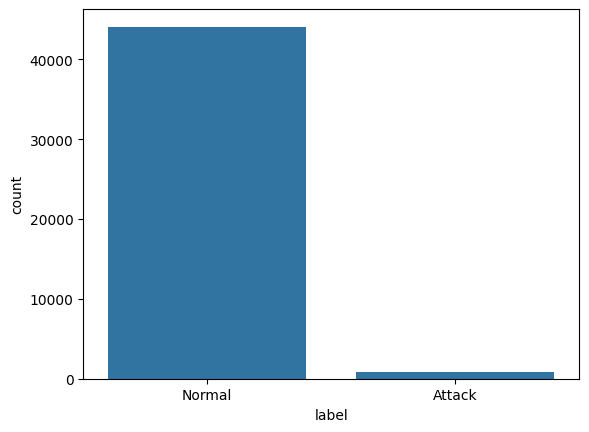

In [21]:
sns.countplot(data=df, x="label")
plt.show()

In [22]:
df["attack_type"].value_counts()

attack_type
Normal                      44100
Low and Slow Brute Force      231
Insider Threat                203
Slow Credential Stuffing      202
Device Spoofing                65
Brute Force                    58
Lateral Movement               49
Impossible Travel              48
Credential Stuffing            44
Name: count, dtype: int64

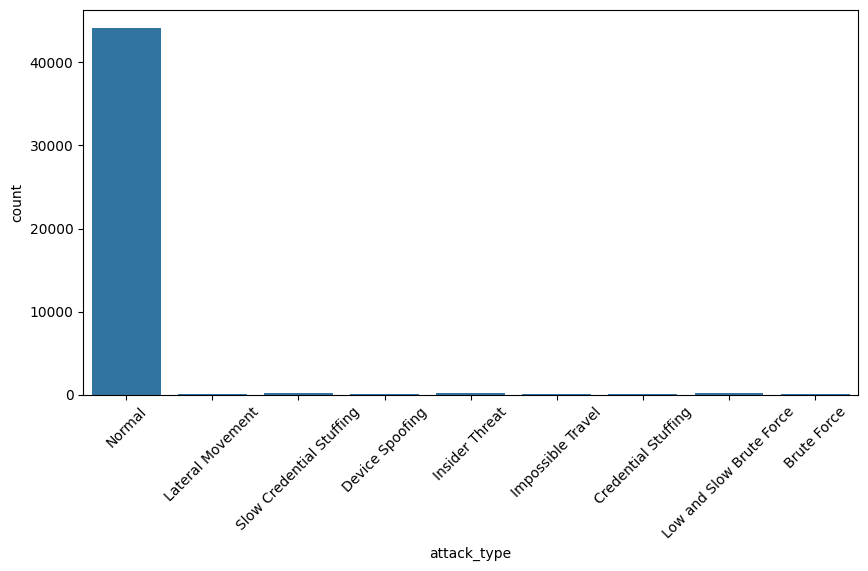

In [23]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="attack_type")
plt.xticks(rotation=45)
plt.show()

In [24]:
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols

Index(['session_duration', 'failed_login_attempts', 'normal_login_start',
       'normal_login_end', 'normal_session_duration',
       'normal_failed_login_attempts', 'login_hour', 'risk_score'],
      dtype='str')

In [25]:
df[numeric_cols].describe()

,session_duration,failed_login_attempts,normal_login_start,normal_login_end,normal_session_duration,normal_failed_login_attempts,login_hour,risk_score
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,119.617533,0.558533,9.002000,11.002000,119.860000,0.272000,9.987622,0.286022
std,37.535854,1.788650,0.837861,0.837861,34.207403,0.444995,1.222235,0.518928
min,15.000000,0.000000,8.000000,10.000000,60.000000,0.000000,0.000000,0.000000
25%,89.000000,0.000000,8.000000,10.000000,89.000000,0.000000,9.000000,0.000000
50%,120.000000,0.000000,9.000000,11.000000,119.000000,0.000000,10.000000,0.000000
75%,149.000000,1.000000,10.000000,12.000000,148.250000,1.000000,11.000000,1.000000
max,327.000000,50.000000,10.000000,12.000000,180.000000,1.000000,12.000000,4.000000


In [26]:
categorical_cols = df.select_dtypes(include="object").columns
categorical_cols

C:\Users\umesh\AppData\Local\Temp\ipykernel_31444\3430876840.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


Index(['entity_id', 'entity_type', 'timestamp', 'logout_time', 'source_ip',
       'geo_location', 'resource_accessed', 'auth_method', 'command_sequence',
       'device_fingerprint', 'label', 'attack_type', 'name', 'email',
       'department', 'office', 'device_id_x', 'device_type',
       'operating_system', 'browser', 'mac_address', 'normal_entity_type',
       'normal_department', 'normal_geo_location', 'device_id_y',
       'normal_device_fingerprint', 'normal_auth_method', 'normal_resources'],
      dtype='str')

In [27]:
corr = df[numeric_cols].corr()

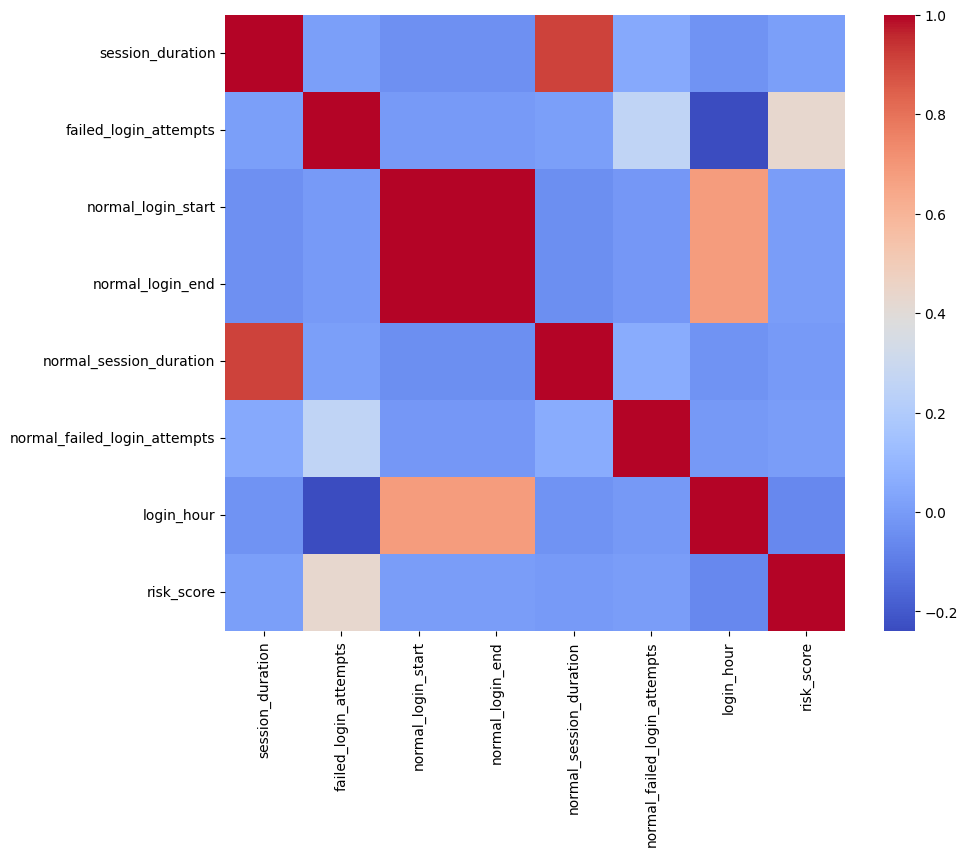

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

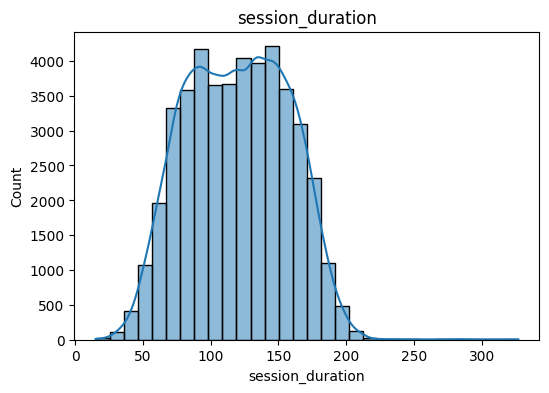

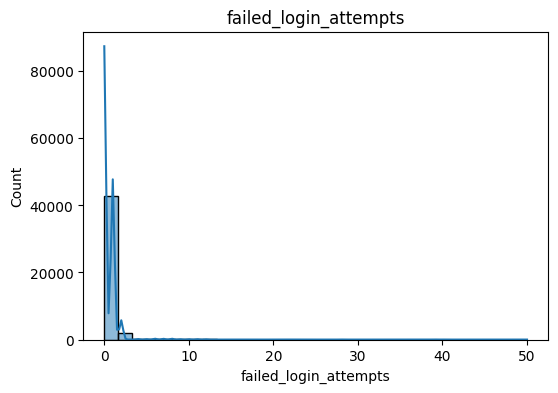

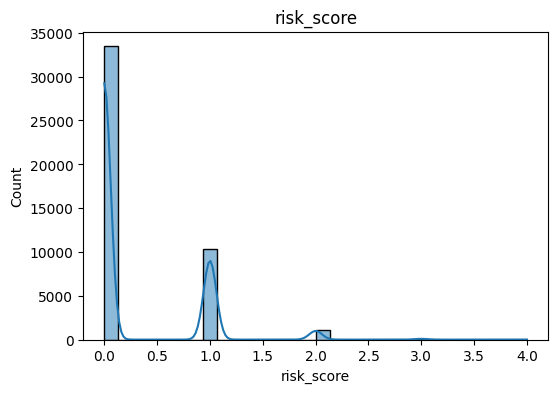

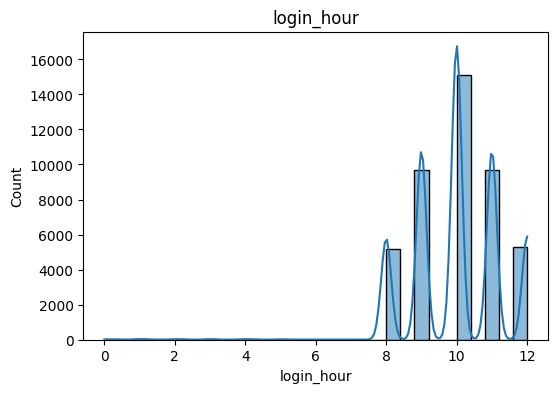

In [29]:
num_cols = [
    "session_duration",
    "failed_login_attempts",
    "risk_score",
    "login_hour"
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
    plt.show()

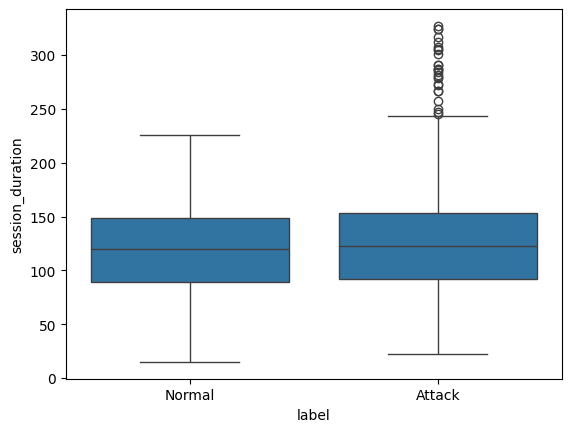

In [30]:
sns.boxplot(x="label", y="session_duration", data=df)
plt.show()

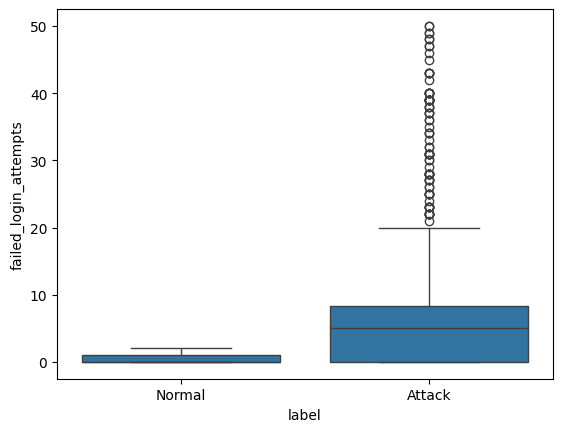

In [31]:
sns.boxplot(x="label", y="failed_login_attempts", data=df)
plt.show()

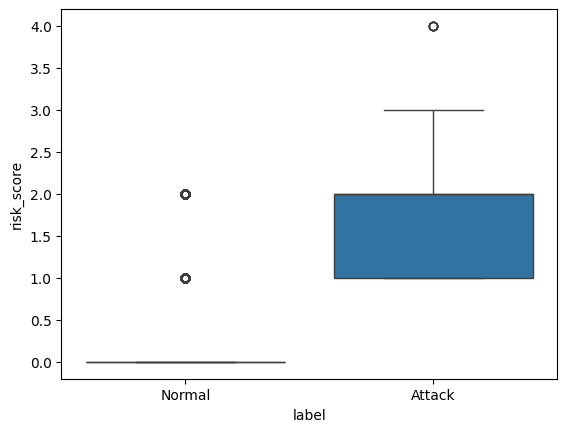

In [32]:
sns.boxplot(x="label", y="risk_score", data=df)
plt.show()

In [33]:
engineered = [
    "location_changed",
    "device_changed",
    "auth_changed",
    "login_time_changed",
    "long_session",
    "high_failed_login",
    "resource_changed"
]

for col in engineered:
    print(df[col].value_counts())

location_changed
False    44952
True        48
Name: count, dtype: int64
device_changed
False    44935
True        65
Name: count, dtype: int64
auth_changed
False    44658
True       342
Name: count, dtype: int64
login_time_changed
False    44898
True       102
Name: count, dtype: int64
long_session
False    44880
True       120
Name: count, dtype: int64
high_failed_login
False    37823
True      7177
Name: count, dtype: int64
resource_changed
False    39983
True      5017
Name: count, dtype: int64


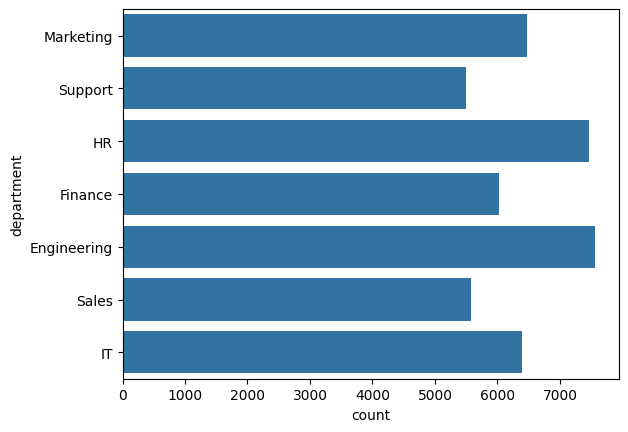

In [34]:
sns.countplot(y="department", data=df)
plt.show()

In [35]:
categorical_cols

Index(['entity_id', 'entity_type', 'timestamp', 'logout_time', 'source_ip',
       'geo_location', 'resource_accessed', 'auth_method', 'command_sequence',
       'device_fingerprint', 'label', 'attack_type', 'name', 'email',
       'department', 'office', 'device_id_x', 'device_type',
       'operating_system', 'browser', 'mac_address', 'normal_entity_type',
       'normal_department', 'normal_geo_location', 'device_id_y',
       'normal_device_fingerprint', 'normal_auth_method', 'normal_resources'],
      dtype='str')

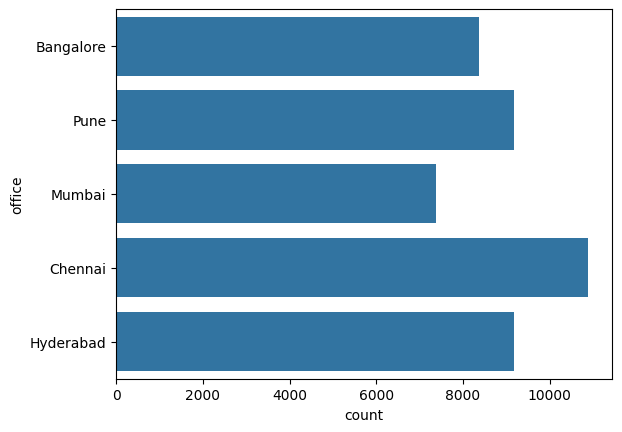

In [36]:
sns.countplot(y="office", data=df)
plt.show()

In [37]:
df.to_csv('../data/processed/processed_logs.csv', index=False)
# or for exact dtype preservation (recommended if you have booleans/categories):
df.to_pickle('../data/processed/eda_output.pkl')